# Installing Packages

In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 61.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.2 MB/s eta 0:00:00


# Load Dataset

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="8Cg8GsglEPyolHoqL1Ju")
project = rf.workspace("naila-athaya-s-workspace").project("person-holding-weapon")
version = project.version(2)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Person-Holding-Weapon-2 in yolov11:: 100%|██████████| 13717/13717 [00:03<00:00, 4250.96it/s] 


# Load Model

In [ ]:
# # load model

# from ultralytics import YOLO

# model_yolov11m = YOLO("/content/ultralytics/ultralytics/cfg/models/11/yolo11m-cbam.yaml")
# model_yolov11m.load("yolo11m.pt")

# model_yolov11m.info()

Transferred 78/659 items from pretrained weights
YOLO11m-cbam summary: 239 layers, 20,186,234 parameters, 20,186,218 gradients, 68.4 GFLOPs


(239, 20186234, 20186218, 68.4078592)

# Train Model

In [ ]:
from ultralytics import YOLO

model_yolov11m = YOLO("yolo11m.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model_yolov11m.train(
    data="/content/Person-Holding-Weapon-2/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    patience=15,
    name="yolov11_only_weapon"
)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Person-Holding-Weapon-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov11_only_weapon, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a1373a6c680>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
# model_yolov11m.train(
#     data="/content/Person-Holding-Weapon-2/data.yaml",
#     epochs=50,
#     imgsz=640,
#     batch=8,
#     patience=15,
#     name="yolov11_only_weapon"
# )

New https://pypi.org/project/ultralytics/8.4.38 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Person-Holding-Weapon-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/ultralytics/ultralytics/cfg/models/11/yolo

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b7cf9383f80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

Save Best Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Kompres folder hasil training menjadi satu file zip
!zip -r /content/yolov11_only_weapon_full.zip /content/runs/detect/yolov11_only_weapon

# Copy file zip tersebut ke Drive kamu
!cp /content/yolov11_only_weapon_full.zip /content/drive/MyDrive/

  adding: content/runs/detect/yolov11_only_weapon/ (stored 0%)
  adding: content/runs/detect/yolov11_only_weapon/train_batch25721.jpg (deflated 19%)
  adding: content/runs/detect/yolov11_only_weapon/val_batch2_pred.jpg (deflated 19%)
  adding: content/runs/detect/yolov11_only_weapon/val_batch1_labels.jpg (deflated 4%)
  adding: content/runs/detect/yolov11_only_weapon/labels.jpg (deflated 49%)
  adding: content/runs/detect/yolov11_only_weapon/train_batch2.jpg (deflated 14%)
  adding: content/runs/detect/yolov11_only_weapon/results.png (deflated 8%)
  adding: content/runs/detect/yolov11_only_weapon/val_batch0_pred.jpg (deflated 5%)
  adding: content/runs/detect/yolov11_only_weapon/confusion_matrix_normalized.png (deflated 28%)
  adding: content/runs/detect/yolov11_only_weapon/train_batch1.jpg (deflated 13%)
  adding: content/runs/detect/yolov11_only_weapon/BoxPR_curve.png (deflated 20%)
  adding: content/runs/detect/yolov11_only_weapon/train_batch0.jpg (deflated 14%)
  adding: content/ru

In [ ]:
!cp /content/runs/detect/yolov11_only_weapon/weights/best.pt /content/drive/MyDrive/yolov11_only_weaponbest.pt

In [ ]:
best_model = YOLO("/content/runs/detect/yolov11_only_weapon/weights/best.pt")

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

from ultralytics import YOLO
best_model = YOLO('/content/drive/MyDrive/yolov11_only_weaponbest.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Inference

In [ ]:
results = best_model.predict(source="/content/Person-Holding-Weapon-2/test/images", save=True, conf=0.25)

Results saved to /content/runs/detect/predict


In [ ]:
!zip -r /content/yolov11_cbam_predict_result.zip /content/runs/detect/predict
!cp /content/yolov11_cbam_predict_result.zip /content/drive/MyDrive/

  adding: content/runs/detect/predict/ (stored 0%)
  adding: content/runs/detect/predict/frame_3_184_jpg.rf.99723f5916d8f5ed9a53371ffa1e3edf.jpg (deflated 4%)
  adding: content/runs/detect/predict/2525_jpg.rf.e7ccb6459a3a1fb8a71c16ac91072b96.jpg (deflated 11%)
  adding: content/runs/detect/predict/frame_2_61_jpg.rf.af8939f2d8e1ce8b41d132abfd43a1e5.jpg (deflated 4%)
  adding: content/runs/detect/predict/frame_745_jpg.rf.1a4ad21047680f2e55d60914ec27d630.jpg (deflated 7%)
  adding: content/runs/detect/predict/1323_jpg.rf.3b1152b25de356011d15eead174f1d53.jpg (deflated 12%)
  adding: content/runs/detect/predict/frame_664_jpg.rf.1bc97d65840fd3a88cd73bd12da2b592.jpg (deflated 4%)
  adding: content/runs/detect/predict/9292_jpg.rf.3f0f9c7634bc3d940d85dabcf0381ca9.jpg (deflated 14%)
  adding: content/runs/detect/predict/frame_518_jpg.rf.ff327769067c989ef3a67dd65ce4adee.jpg (deflated 5%)
  adding: content/runs/detect/predict/frame_2_124_jpg.rf.8cfba008e381d0fb0de1bf06c342dbaa.jpg (deflated 5%)
  

# Test Model

In [ ]:
metrics = best_model.val(
    data='/content/Person-Holding-Weapon-2/data.yaml',
    split='test'
)

print(metrics)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,031,574 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6.9±3.4 MB/s, size: 35.2 KB)
val: Scanning /content/Person-Holding-Weapon-2/test/labels... 857 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 857/857 479.5it/s 1.8s
val: New cache created: /content/Person-Holding-Weapon-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 1.9it/s 28.1s
                   all        857       1588      0.913      0.707      0.751      0.538
    person hold weapon        732        732      0.916      0.903      0.948      0.696
                weapon        856        856      0.911      0.511      0.554      0.379
Speed: 1.8ms preprocess, 25.5ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils

In [ ]:
!zip -r /content/yolov11_cbam_test_result.zip /content/runs/detect/val/
!cp /content/yolov11_cbam_test_result.zip /content/drive/MyDrive/

  adding: content/ultralytics/runs/detect/val/ (stored 0%)
  adding: content/ultralytics/runs/detect/val/val_batch2_pred.jpg (deflated 18%)
  adding: content/ultralytics/runs/detect/val/val_batch1_labels.jpg (deflated 5%)
  adding: content/ultralytics/runs/detect/val/val_batch0_pred.jpg (deflated 4%)
  adding: content/ultralytics/runs/detect/val/confusion_matrix_normalized.png (deflated 29%)
  adding: content/ultralytics/runs/detect/val/BoxPR_curve.png (deflated 12%)
  adding: content/ultralytics/runs/detect/val/val_batch0_labels.jpg (deflated 5%)
  adding: content/ultralytics/runs/detect/val/val_batch2_labels.jpg (deflated 20%)
  adding: content/ultralytics/runs/detect/val/BoxP_curve.png (deflated 14%)
  adding: content/ultralytics/runs/detect/val/confusion_matrix.png (deflated 29%)
  adding: content/ultralytics/runs/detect/val/BoxR_curve.png (deflated 12%)
  adding: content/ultralytics/runs/detect/val/val_batch1_pred.jpg (deflated 5%)
  adding: content/ultralytics/runs/detect/val/Box

# Mediapipe (extract body keypoint)

In [ ]:
# !pip install opencv-python matplotlib tqdm -q

In [ ]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.4 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

from ultralytics import YOLO

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


# CONFIG

IMG_DIR = "/content/Person-Holding-Weapon-2/test/images"
LABEL_DIR = "/content/Person-Holding-Weapon-2/test/labels"
OUTPUT_DIR = "/content/yolo_only_mediapipe_results"

MODEL_PATH = best_model  # pastikan ini model YOLO

CONF_THRES = 0.3   # 🔥 diturunkan (biar recall naik)
IOU_THRES = 0.5

os.makedirs(OUTPUT_DIR, exist_ok=True)

Jumlah image: 857


100%|██████████| 857/857 [00:58<00:00, 14.56it/s]



===== HASIL FINAL FUSION (ADVANCED) =====
Precision: 0.7597
Recall: 0.8014
mAP50: 0.7513


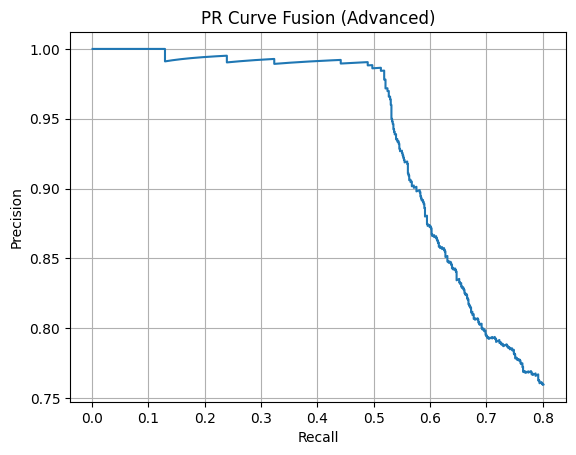

In [ ]:
print("Jumlah image:", len(os.listdir(IMG_DIR)))


model = YOLO(MODEL_PATH)

# DOWNLOAD MEDIAPIPE MODEL
!wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task -O pose_landmarker.task

# MEDIAPIPE SETUP
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE
)
pose = vision.PoseLandmarker.create_from_options(options)


# IOU FUNCTION
def compute_iomin(box1, box2):
    x1, y1, x2, y2 = box1
    x1g, y1g, x2g, y2g = box2

    xi1 = max(x1, x1g)
    yi1 = max(y1, y1g)
    xi2 = min(x2, x2g)
    yi2 = min(y2, y2g)

    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    area1 = (x2 - x1) * (y2 - y1)
    area2 = (x2g - x1g) * (y2g - y1g)

    return inter / (min(area1, area2) + 1e-6)


# EVALUATION
all_scores = []
all_tp = []
total_gt = 0

image_files = [f for f in os.listdir(IMG_DIR) if f.endswith(('.jpg','.png','.jpeg'))]

for img_name in tqdm(image_files):

    try:
        img_path = os.path.join(IMG_DIR, img_name)
        label_path = os.path.join(LABEL_DIR, img_name.replace('.jpg','.txt').replace('.png','.txt'))

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w, _ = img.shape


        # YOLO INFERENCE
        results = model(img, conf=CONF_THRES, verbose=False)[0]

        weapon_boxes = []
        weapon_scores = []
        person_boxes = []

        for box in results.boxes:
            cls = int(box.cls)
            conf = float(box.conf)
            xyxy = box.xyxy[0].cpu().numpy()

            if cls == 1:
                weapon_boxes.append(xyxy)
                weapon_scores.append(conf)

            elif cls == 0:
                person_boxes.append(xyxy)


        # MEDIAPIPE POSE
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)
        mp_result = pose.detect(mp_image)

        wrists = []
        elbows = []

        if mp_result.pose_landmarks:
            landmarks = mp_result.pose_landmarks[0]

            for idx in [15, 16]:
                lm = landmarks[idx]
                if lm.visibility > 0.5:
                    wrists.append([lm.x * w, lm.y * h])

            for idx in [13, 14]:
                lm = landmarks[idx]
                if lm.visibility > 0.5:
                    elbows.append([lm.x * w, lm.y * h])


        # FUSION
        fused_boxes = []
        fused_scores = []

        for box, score in zip(weapon_boxes, weapon_scores):

            cx = (box[0] + box[2]) / 2
            cy = (box[1] + box[3]) / 2

            min_dist = 999

            for wx, wy in wrists:
                dist = np.sqrt((cx - wx)**2 + (cy - wy)**2)
                dist_norm = dist / w
                min_dist = min(min_dist, dist_norm)

            score_new = score

            if min_dist < 0.25:
                score_new += 0.2
            else:
                score_new -= 0.2

            if score_new > 0.25:
                fused_boxes.append(box)
                fused_scores.append(score_new)

        if len(weapon_boxes) == 0 and len(person_boxes) > 0 and len(wrists) > 0:

            for i in range(min(len(wrists), len(elbows))):

                wx, wy = wrists[i]
                ex, ey = elbows[i]

                dx = wx - ex
                dy = wy - ey

                px = wx + dx * 0.5
                py = wy + dy * 0.5

                size = 0.08 * w

                x1 = max(0, px - size/2)
                y1 = max(0, py - size/2)
                x2 = min(w, px + size/2)
                y2 = min(h, py + size/2)

                fused_boxes.append([x1, y1, x2, y2])
                fused_scores.append(0.35)


        # VISUALIZATION
        vis_img = img.copy()

        for box, score in zip(fused_boxes, fused_scores):
            x1, y1, x2, y2 = map(int, box)

            cv2.rectangle(vis_img, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(vis_img, f"{score:.2f}", (x1, y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

        if mp_result.pose_landmarks:
            for lm in mp_result.pose_landmarks[0]:
                if lm.visibility > 0.5:
                    x, y = int(lm.x * w), int(lm.y * h)
                    cv2.circle(vis_img, (x,y), 3, (0,0,255), -1)

        connections = [
            (11,13), (13,15),
            (12,14), (14,16)
        ]

        if mp_result.pose_landmarks:
            landmarks = mp_result.pose_landmarks[0]
            for p1, p2 in connections:
                lm1, lm2 = landmarks[p1], landmarks[p2]
                if lm1.visibility > 0.5 and lm2.visibility > 0.5:
                    x1, y1 = int(lm1.x * w), int(lm1.y * h)
                    x2, y2 = int(lm2.x * w), int(lm2.y * h)
                    cv2.line(vis_img, (x1,y1), (x2,y2), (255,0,0), 2)


        # SAVE IMAGE
        save_path = os.path.join(OUTPUT_DIR, img_name)
        cv2.imwrite(save_path, vis_img)


        # LOAD GROUND TRUTH
        gt_boxes = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    cls, xc, yc, bw, bh = map(float, line.split())
                    if int(cls) == 1:
                        x1 = (xc - bw/2) * w
                        y1 = (yc - bh/2) * h
                        x2 = (xc + bw/2) * w
                        y2 = (yc + bh/2) * h
                        gt_boxes.append([x1,y1,x2,y2])

        total_gt += len(gt_boxes)

        matched = set()

        for box, score in zip(fused_boxes, fused_scores):

            best_iou = 0
            best_idx = -1

            for i, gt in enumerate(gt_boxes):
                iou = compute_iomin(box, gt)
                if iou > best_iou:
                    best_iou = iou
                    best_idx = i

            if best_iou >= IOU_THRES and best_idx not in matched:
                all_tp.append(1)
                matched.add(best_idx)
            else:
                all_tp.append(0)

            all_scores.append(score)

    except Exception as e:
        print("Error:", img_name, e)


# METRICS
indices = np.argsort(-np.array(all_scores))
tp = np.array(all_tp)[indices]
fp = 1 - tp

cum_tp = np.cumsum(tp)
cum_fp = np.cumsum(fp)

precision = cum_tp / (cum_tp + cum_fp + 1e-6)
recall = cum_tp / (total_gt + 1e-6)

ap = np.trapezoid(precision, recall)

print("\n===== HASIL FINAL FUSION (ADVANCED) =====")
print(f"Precision: {precision[-1]:.4f}")
print(f"Recall: {recall[-1]:.4f}")
print(f"mAP50: {ap:.4f}")

# PR CURVE
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve Fusion (Advanced)")
plt.grid()
plt.show()

In [ ]:
# !zip -r yolo_only_mediapipe_results.zip /content/yolo_only_mediapipe_results
# !cp yolo_only_mediapipe_results.zip /content/MyDrive

  adding: content/yolo_only_mediapipe_results/ (stored 0%)
  adding: content/yolo_only_mediapipe_results/848_jpg.rf.a3ef4a1a966db60a07784cdb5a4059ae.jpg (deflated 12%)
  adding: content/yolo_only_mediapipe_results/frame_2_21_jpg.rf.34617799f5885efde45dfa166c24d22a.jpg (deflated 4%)
  adding: content/yolo_only_mediapipe_results/1539_jpg.rf.f2d91917202a345f5094b62604197d90.jpg (deflated 12%)
  adding: content/yolo_only_mediapipe_results/3106_jpg.rf.bfd5c67cd9b4c05f8a6790ecd7c95a00.jpg (deflated 13%)
  adding: content/yolo_only_mediapipe_results/frame_2_127_jpg.rf.2b4861bfb99b75d64832cc33ba39abd1.jpg (deflated 5%)
  adding: content/yolo_only_mediapipe_results/frame_2_62_jpg.rf.a4e1e66453fcce6f08b22896032ee78f.jpg (deflated 4%)
  adding: content/yolo_only_mediapipe_results/frame_2_76_jpg.rf.a09b589c5b0ebc9e50780d358b99d07d.jpg (deflated 4%)
  adding: content/yolo_only_mediapipe_results/frame_3_114_jpg.rf.25d89508498829b947966dbc1fd753e7.jpg (deflated 4%)
  adding: content/yolo_only_mediapi